In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
# import file 
FILE_PATH = ["elastic1.csv", "elastic2.csv"]
def read_csv(file_path):
    df = pd.read_csv(file_path, low_memory=False)
    return df

In [3]:
# read and concatenate the csvs then show with head()
dfs = [read_csv(path) for path in FILE_PATH]
df = pd.concat(dfs, ignore_index=True)
df.head()

,@timestamp,@version,app_uuid,device_type,end_time,event,firmware_version,game_uuid,generic_string,geoip.country_code,hostname,log_level,original.time,start_time,original.timezone,software_version
0,"Jan 28, 2026 @ 01:43:16.913",1,0827b0e1-909c-46b6-920a-068db839cf71,0,"Jan 28, 2026 @ 01:43:16.913",GAME_END,6.02-0.3,8277e06a-3b8e-4950-ac58-8bc8f8c05149,BALLGAME,GB,vv-000732a85baa,3,"Jan 28, 2026 @ 02:43:16.913",NaN,NaN,NaN
1,"Jan 28, 2026 @ 01:43:17.083",1,0827b0e1-909c-46b6-920a-068db839cf71,0,-,GAME_START,6.02-0.3,16b63033-eb00-4e53-9b8c-e77c625a04fe,INSTRUMENTS,GB,vv-000732a85baa,3,"Jan 28, 2026 @ 02:43:17.083",NaN,NaN,NaN
2,"Jan 28, 2026 @ 01:48:29.286",1,0827b0e1-909c-46b6-920a-068db839cf71,0,"Jan 28, 2026 @ 01:48:29.286",GAME_END,6.02-0.3,16b63033-eb00-4e53-9b8c-e77c625a04fe,INSTRUMENTS,GB,vv-000732a85baa,3,"Jan 28, 2026 @ 02:48:29.286",NaN,NaN,NaN
3,"Jan 28, 2026 @ 01:48:29.504",1,0827b0e1-909c-46b6-920a-068db839cf71,0,-,GAME_START,6.02-0.3,554f6e13-ef3a-4449-a5db-31326c12766e,BEACHCOMBING,GB,vv-000732a85baa,3,"Jan 28, 2026 @ 02:48:29.504",NaN,NaN,NaN
4,"Jan 28, 2026 @ 01:53:40.556",1,0827b0e1-909c-46b6-920a-068db839cf71,0,"Jan 28, 2026 @ 01:53:40.556",GAME_END,6.02-0.3,554f6e13-ef3a-4449-a5db-31326c12766e,BEACHCOMBING,GB,vv-000732a85baa,3,"Jan 28, 2026 @ 02:53:40.556",NaN,NaN,NaN


In [4]:
df.shape

(876428, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 876428 entries, 0 to 876427
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   @timestamp          876428 non-null  str  
 1   @version            876428 non-null  int64
 2   app_uuid            876428 non-null  str  
 3   device_type         876428 non-null  int64
 4   end_time            876428 non-null  str  
 5   event               876428 non-null  str  
 6   firmware_version    876428 non-null  str  
 7   game_uuid           876428 non-null  str  
 8   generic_string      876428 non-null  str  
 9   geoip.country_code  876428 non-null  str  
 10  hostname            876428 non-null  str  
 11  log_level           876428 non-null  int64
 12  original.time       876428 non-null  str  
 13  start_time          391653 non-null  str  
 14  original.timezone   391653 non-null  str  
 15  software_version    391653 non-null  str  
dtypes: int64(3), str(13)
memory usa

In [6]:
df_query = df.copy(deep=True)

In [7]:
# datetime conversion and sanity check
print("Total rows before:", len(df_query))

clean_timestamps = df_query['@timestamp'].str.replace(' @ ', ' ')
clean_localtime = df_query['original.time'].str.replace(' @ ', ' ')

df_query['@timestamp'] = pd.to_datetime(clean_timestamps, errors='coerce')
df_query['original.time'] = pd.to_datetime(clean_localtime, errors='coerce')

missing_dates = df_query['@timestamp'].isna().sum()
print(f"Dates that failed to parse: {missing_dates}")

df_query = df_query.dropna(subset=['@timestamp'])
print("Total rows after:", len(df_query))

Total rows before: 876428
Dates that failed to parse: 0
Total rows after: 876428


In [8]:
df_query['date'] = df_query['@timestamp'].dt.date
df_query['time'] = df_query['@timestamp'].dt.time

In [9]:
# get first entry per device to determine activation date
activation_dates = df_query.groupby('hostname')['date'].min().reset_index()
activation_dates = activation_dates.rename(columns={'date': 'activation_date'})

df_query = df_query.merge(activation_dates, on='hostname', how='left')
df_query.head()

,@timestamp,@version,app_uuid,device_type,end_time,event,firmware_version,game_uuid,generic_string,geoip.country_code,hostname,log_level,original.time,start_time,original.timezone,software_version,date,time,activation_date
0,2026-01-28 01:43:16.913,1,0827b0e1-909c-46b6-920a-068db839cf71,0,"Jan 28, 2026 @ 01:43:16.913",GAME_END,6.02-0.3,8277e06a-3b8e-4950-ac58-8bc8f8c05149,BALLGAME,GB,vv-000732a85baa,3,2026-01-28 02:43:16.913,NaN,NaN,NaN,2026-01-28,01:43:16.913000,2026-01-22
1,2026-01-28 01:43:17.083,1,0827b0e1-909c-46b6-920a-068db839cf71,0,-,GAME_START,6.02-0.3,16b63033-eb00-4e53-9b8c-e77c625a04fe,INSTRUMENTS,GB,vv-000732a85baa,3,2026-01-28 02:43:17.083,NaN,NaN,NaN,2026-01-28,01:43:17.083000,2026-01-22
2,2026-01-28 01:48:29.286,1,0827b0e1-909c-46b6-920a-068db839cf71,0,"Jan 28, 2026 @ 01:48:29.286",GAME_END,6.02-0.3,16b63033-eb00-4e53-9b8c-e77c625a04fe,INSTRUMENTS,GB,vv-000732a85baa,3,2026-01-28 02:48:29.286,NaN,NaN,NaN,2026-01-28,01:48:29.286000,2026-01-22
3,2026-01-28 01:48:29.504,1,0827b0e1-909c-46b6-920a-068db839cf71,0,-,GAME_START,6.02-0.3,554f6e13-ef3a-4449-a5db-31326c12766e,BEACHCOMBING,GB,vv-000732a85baa,3,2026-01-28 02:48:29.504,NaN,NaN,NaN,2026-01-28,01:48:29.504000,2026-01-22
4,2026-01-28 01:53:40.556,1,0827b0e1-909c-46b6-920a-068db839cf71,0,"Jan 28, 2026 @ 01:53:40.556",GAME_END,6.02-0.3,554f6e13-ef3a-4449-a5db-31326c12766e,BEACHCOMBING,GB,vv-000732a85baa,3,2026-01-28 02:53:40.556,NaN,NaN,NaN,2026-01-28,01:53:40.556000,2026-01-22


In [10]:
df_query['device_type'] = pd.to_numeric(df_query['device_type'], errors='coerce')

In [11]:
df_query['date'] = pd.to_datetime(df_query['date'])
df_query['activation_date'] = pd.to_datetime(df_query['activation_date'])

df_query['days_since_activation'] = (df_query['date'] - df_query['activation_date']).dt.days

print(df_query[['hostname', 'date', 'activation_date', 'days_since_activation']].head(10))

          hostname       date activation_date  days_since_activation
0  vv-000732a85baa 2026-01-28      2026-01-22                      6
1  vv-000732a85baa 2026-01-28      2026-01-22                      6
2  vv-000732a85baa 2026-01-28      2026-01-22                      6
3  vv-000732a85baa 2026-01-28      2026-01-22                      6
4  vv-000732a85baa 2026-01-28      2026-01-22                      6
5  vv-000732a85baa 2026-01-28      2026-01-22                      6
6  vv-000732a85baa 2026-01-28      2026-01-22                      6
7  vv-000732a85baa 2026-01-28      2026-01-22                      6
8  vv-000732a85baa 2026-01-28      2026-01-22                      6
9  vv-000732a85baa 2026-01-28      2026-01-22                      6


In [12]:
print(df_query['activation_date'].value_counts())

activation_date
2025-12-03    67063
2024-06-24    63158
2026-03-05    44651
2025-11-25    39693
2026-02-18    34967
              ...  
2024-06-09        2
2023-11-13        1
2024-05-06        1
2025-08-14        1
2025-09-25        1
Name: count, Length: 331, dtype: int64


In [13]:
day_zero_events = df_query[df_query['days_since_activation'] == 0]
print(day_zero_events[['hostname', 'date', 'event', 'generic_string', 'activation_date', 'days_since_activation']].head(10))

           hostname       date       event       generic_string  \
27  vv-0007328982fa 2026-01-28    GAME_END              FLOWERS   
28  vv-0007328982fa 2026-01-28  GAME_START  MUSIC_HERO_ORIGINAL   
29  vv-0007328982fa 2026-01-28    GAME_END  MUSIC_HERO_ORIGINAL   
30  vv-0007328982fa 2026-01-28  GAME_START              FLOWERS   
31  vv-0007328982fa 2026-01-28    GAME_END              FLOWERS   
32  vv-0007328982fa 2026-01-28  GAME_START    DRAWINGS_ORIGINAL   
33  vv-0007328982fa 2026-01-28    GAME_END    DRAWINGS_ORIGINAL   
34  vv-0007328982fa 2026-01-28  GAME_START               PUZZLE   
35  vv-0007328982fa 2026-01-28    GAME_END               PUZZLE   
36  vv-0007328982fa 2026-01-28  GAME_START               PUZZLE   

   activation_date  days_since_activation  
27      2026-01-28                      0  
28      2026-01-28                      0  
29      2026-01-28                      0  
30      2026-01-28                      0  
31      2026-01-28                      0 

**<h4>Daily usage trends</h4>**

In [41]:
df_query['original.timezone'].value_counts()

original.timezone
CET +0100     260491
CEST +0200    128668
AEST +1000      2494
Name: count, dtype: int64

In [ ]:
# Build a per-device timezone from any row that has original.timezone data
device_tz = (
    df_query[
        df_query['original.timezone'].notna() &
        (df_query['original.timezone'] != 'NaN') &
        (df_query['original.timezone'] != '-')
    ]
    .groupby('hostname')['original.timezone']
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={'original.timezone': 'device_timezone'})
)

print(f"Devices with a known timezone: {len(device_tz)}")
print(device_tz['device_timezone'].value_counts())

# Per-country fallback: most common timezone among devices that have one
hostname_country = df_query[['hostname', 'geoip.country_code']].drop_duplicates('hostname')
device_tz_country = device_tz.merge(hostname_country, on='hostname', how='left')
country_tz = (
    device_tz_country[
        device_tz_country['geoip.country_code'].notna() &
        (device_tz_country['geoip.country_code'] != '-')
    ]
    .groupby('geoip.country_code')['device_timezone']
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={'device_timezone': 'country_timezone'})
)

print("\nCountry timezone fallbacks:")
print(country_tz)

# All GAME_START events, merge device timezone then country fallback
df_games = df_query[df_query['event'] == 'GAME_START'].copy()
df_games = df_games.merge(device_tz, on='hostname', how='left')
df_games = df_games.merge(country_tz, on='geoip.country_code', how='left')
df_games['device_timezone'] = df_games['device_timezone'].fillna(df_games['country_timezone'])

# Extract UTC offset from e.g. "CET +0100" → "+0100"
df_games['tz_offset'] = df_games['device_timezone'].str.extract(r'([+-]\d{4})')

df_games['utc_offset'] = pd.to_timedelta(
    df_games['tz_offset'].str[0] +
    df_games['tz_offset'].str[1:3] + ':' +
    df_games['tz_offset'].str[3:5] + ':' +
    '00',
    errors='coerce'
)
# Only fall back to UTC if country timezone also unknown
df_games['utc_offset'] = df_games['utc_offset'].fillna(pd.Timedelta(0))

df_games['local_time'] = df_games['@timestamp'] + df_games['utc_offset']
df_games['local_hour'] = df_games['local_time'].dt.hour

time_of_day_trend = df_games.groupby('local_hour').size().reset_index(name='total_games_played')

print("\nBusiest hours for usage:")
print(time_of_day_trend.sort_values(by='total_games_played', ascending=False))

<h3>Localized Time</h3>

In [15]:
'''import pytz

df_query['@timestamp'] = pd.to_datetime(df_query['@timestamp'], errors='coerce', utc=True)

def get_local_time(row):
    country_code = row['geoip.country_code']
    utc_time = row['@timestamp']
    
    if pd.isna(country_code) or pd.isna(utc_time):
        return np.nan 
        
    try:
        tz_string = pytz.country_timezones[country_code][0]
        local_tz = pytz.timezone(tz_string)
        local_time = utc_time.astimezone(local_tz)
        return local_time.strftime('%H:%M:%S')
        
    except KeyError:
        return utc_time.strftime('%H:%M:%S')

df_query['local_time'] = df_query.apply(get_local_time, axis=1)

print(df_query[['@timestamp', 'geoip.country_code', 'local_time']].head())

df_games['@timestamp'] = pd.to_datetime(df_games['@timestamp'], errors='coerce', utc=True)
df_games['local_time'] = df_games.apply(get_local_time, axis=1)
df_games['local_hour'] = df_games['local_time'].str.slice(0, 2).astype(float)
'''

"import pytz\n\ndf_query['@timestamp'] = pd.to_datetime(df_query['@timestamp'], errors='coerce', utc=True)\n\ndef get_local_time(row):\n    country_code = row['geoip.country_code']\n    utc_time = row['@timestamp']\n\n    if pd.isna(country_code) or pd.isna(utc_time):\n        return np.nan \n\n    try:\n        tz_string = pytz.country_timezones[country_code][0]\n        local_tz = pytz.timezone(tz_string)\n        local_time = utc_time.astimezone(local_tz)\n        return local_time.strftime('%H:%M:%S')\n\n    except KeyError:\n        return utc_time.strftime('%H:%M:%S')\n\ndf_query['local_time'] = df_query.apply(get_local_time, axis=1)\n\nprint(df_query[['@timestamp', 'geoip.country_code', 'local_time']].head())\n\ndf_games['@timestamp'] = pd.to_datetime(df_games['@timestamp'], errors='coerce', utc=True)\ndf_games['local_time'] = df_games.apply(get_local_time, axis=1)\ndf_games['local_hour'] = df_games['local_time'].str.slice(0, 2).astype(float)\n"

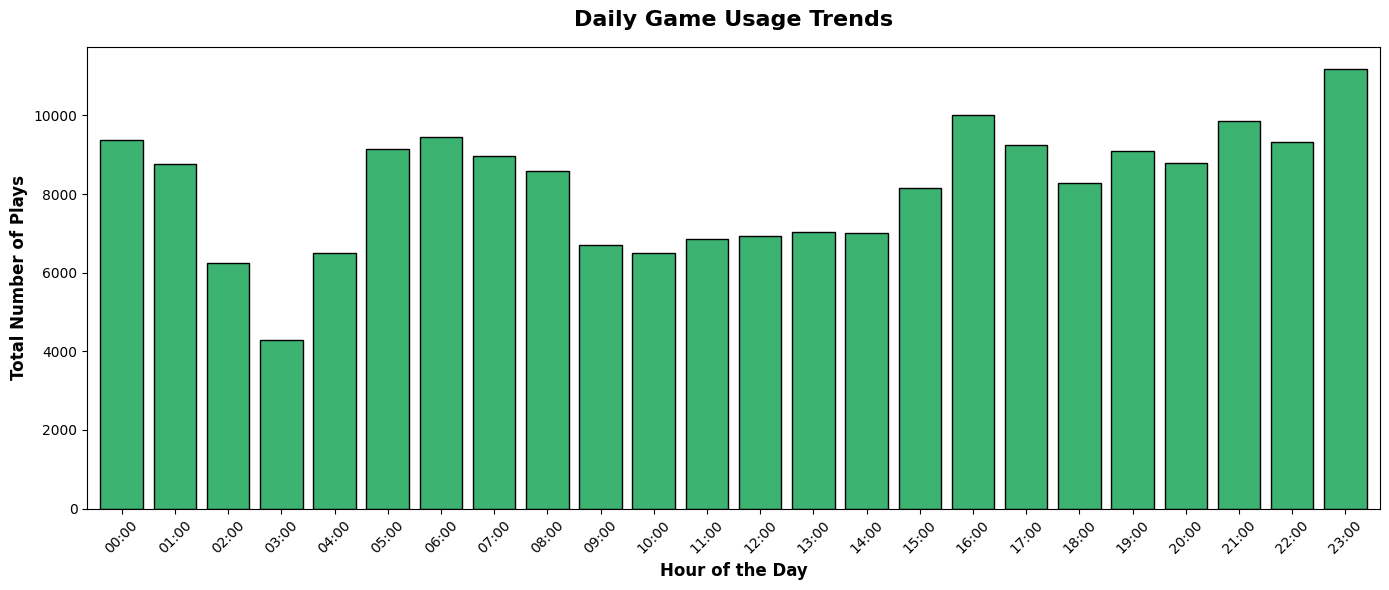

In [60]:
hourly_counts = df_games['local_hour'].value_counts().sort_index()
plt.figure(figsize=(14, 6))
hourly_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black', width=0.8)
plt.title('Daily Game Usage Trends', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Plays', fontsize=12, fontweight='bold')
hours_present = hourly_counts.index.astype(int)
plt.xticks(
    ticks=range(len(hours_present)), 
    labels=[f"{h:02d}:00" for h in hours_present], 
    rotation=45
)
plt.tight_layout()
plt.show()

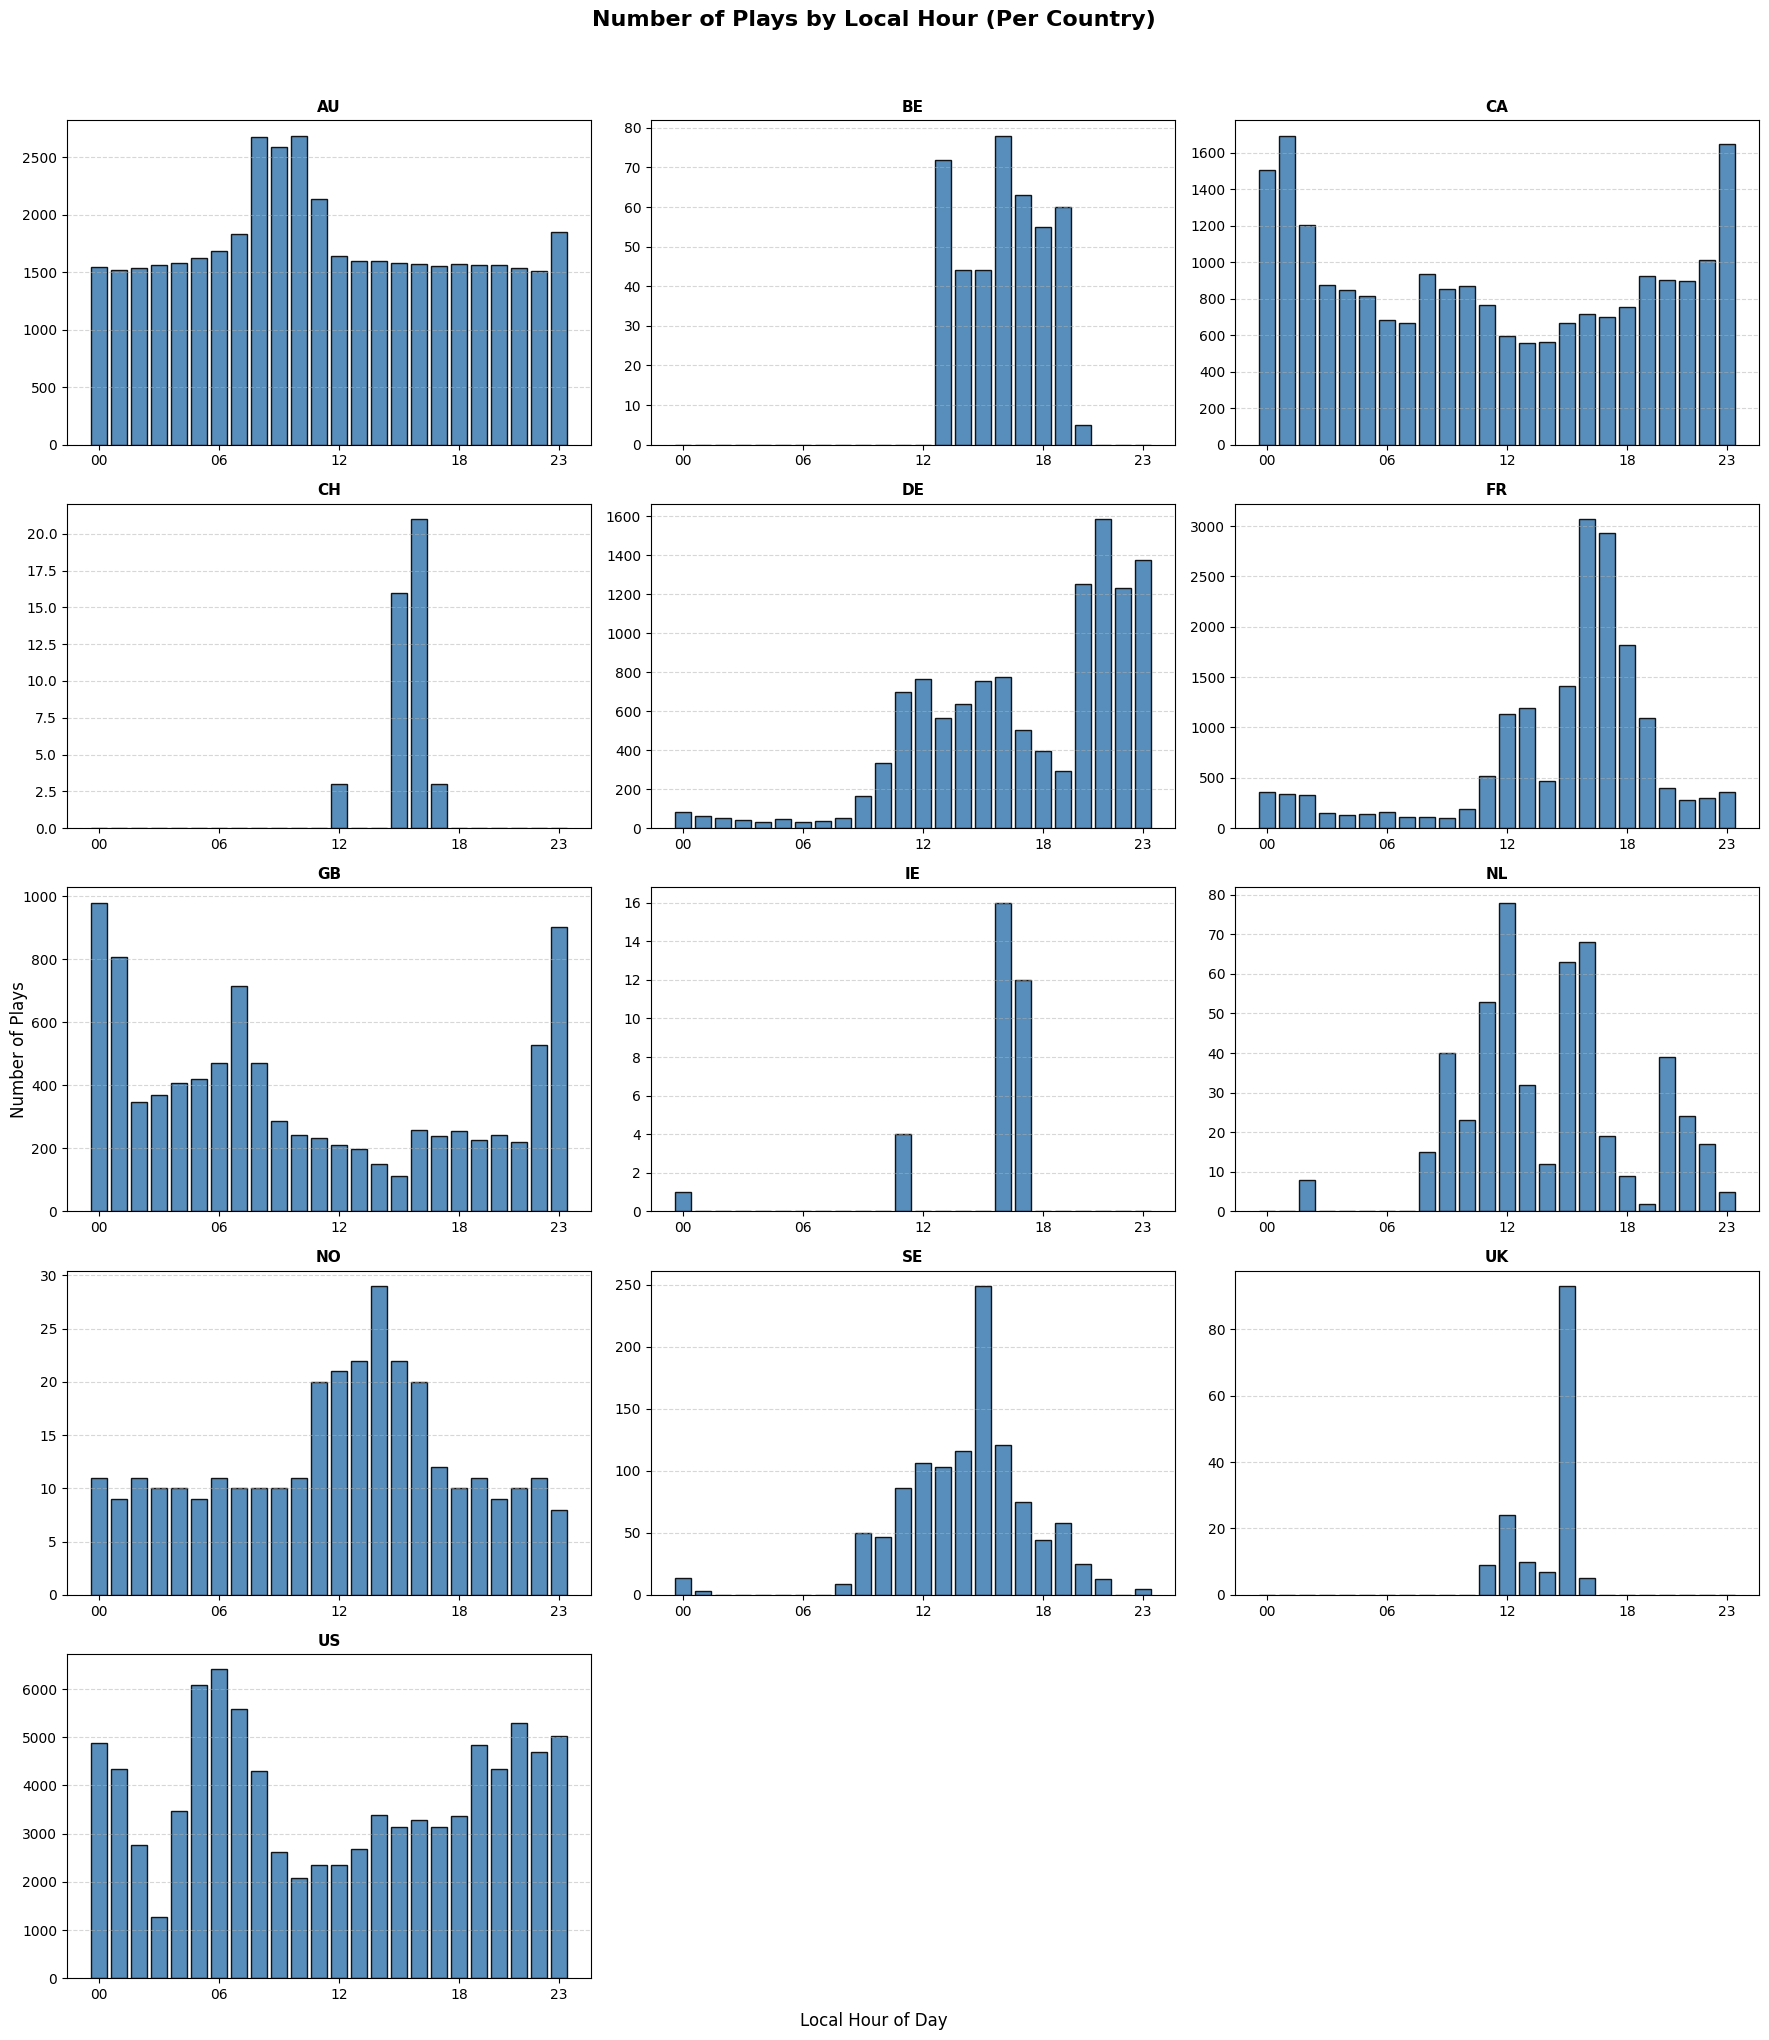

In [61]:
# Per-country hourly play distribution using local time
df_country_hour = df_games.copy()
df_country_hour = df_country_hour[df_country_hour['geoip.country_code'].notna()]
df_country_hour = df_country_hour[df_country_hour['geoip.country_code'] != '-']

# Ensure hour is valid integer from 0 to 23
df_country_hour['local_hour'] = pd.to_numeric(df_country_hour['local_hour'], errors='coerce')
df_country_hour = df_country_hour.dropna(subset=['local_hour'])
df_country_hour['local_hour'] = df_country_hour['local_hour'].astype(int)
df_country_hour = df_country_hour[(df_country_hour['local_hour'] >= 0) & (df_country_hour['local_hour'] <= 23)]

country_hourly = (
    df_country_hour
    .groupby(['geoip.country_code', 'local_hour'])
    .size()
    .reset_index(name='plays')
)

countries = sorted(country_hourly['geoip.country_code'].unique())
cols = 3
rows = int(np.ceil(len(countries) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, country in enumerate(countries):
    ax = axes[i]
    country_data = country_hourly[country_hourly['geoip.country_code'] == country].set_index('local_hour')['plays']
    country_data = country_data.reindex(range(24), fill_value=0)

    ax.bar(range(24), country_data.values, color='steelblue', edgecolor='black', alpha=0.9)
    ax.set_title(f'{country}', fontsize=11, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xticklabels(['00', '06', '12', '18', '23'])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

for j in range(len(countries), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Number of Plays by Local Hour (Per Country)', fontsize=16, fontweight='bold', y=1.02)
fig.supxlabel('Local Hour of Day')
fig.supylabel('Number of Plays')
plt.tight_layout()
plt.show()

<h3>Seasonal Trend</h3>

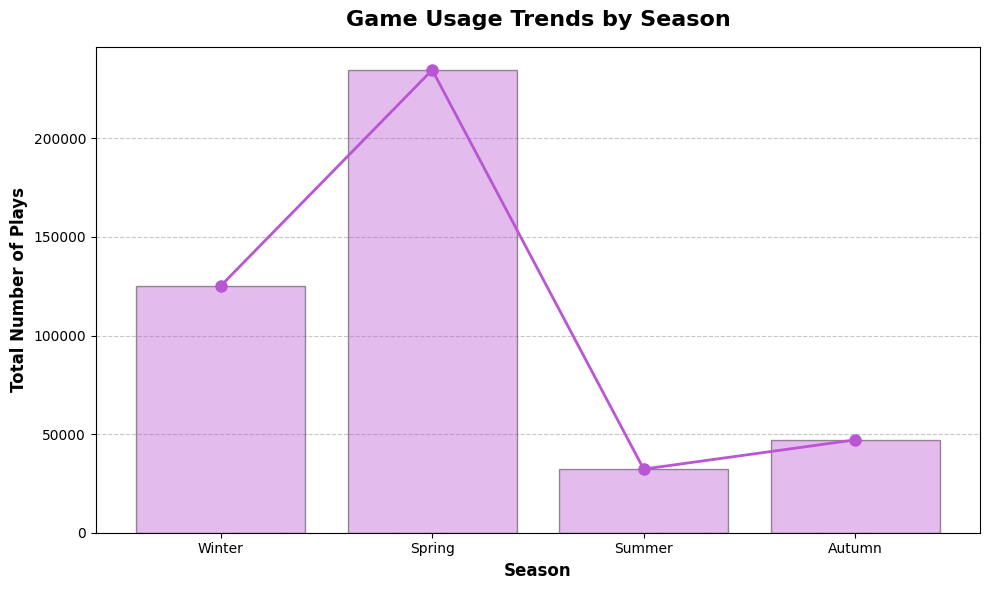

In [18]:

month_to_season = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 
    4: 'Spring', 5: 'Spring', 6: 'Summer', 
    7: 'Summer', 8: 'Summer', 9: 'Autumn', 
    10: 'Autumn', 11: 'Autumn', 12: 'Winter'
}

df_games['season'] = df_games['@timestamp'].dt.month.map(month_to_season)

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
df_games['season'] = pd.Categorical(df_games['season'], categories=season_order, ordered=True)

seasonal_counts = df_games['season'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(seasonal_counts.index, seasonal_counts.values, color='mediumorchid', marker='o', linestyle='-', linewidth=2, markersize=8, zorder=3)
plt.bar(seasonal_counts.index, seasonal_counts.values, color='mediumorchid', alpha=0.4, edgecolor='black', zorder=2)
plt.title('Game Usage Trends by Season', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Plays', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

<h3>Session Durations</h3>

In [19]:
df_sorted = df_query.sort_values(['game_uuid', '@timestamp']).copy()

starts_ends = df_sorted[df_sorted['event'].isin(['GAME_START', 'GAME_END'])].copy()

starts_ends['next_event'] = starts_ends.groupby('game_uuid')['event'].shift(-1)
starts_ends['next_timestamp'] = starts_ends.groupby('game_uuid')['@timestamp'].shift(-1)

valid_sessions = starts_ends[
    (starts_ends['event'] == 'GAME_START') & 
    (starts_ends['next_event'] == 'GAME_END')
].copy()

valid_sessions['duration_minutes'] = (valid_sessions['next_timestamp'] - valid_sessions['@timestamp']).dt.total_seconds() / 60

df_sessions = valid_sessions[['game_uuid', 'generic_string', '@timestamp', 'next_timestamp', 'duration_minutes']].copy()
df_sessions.rename(columns={'@timestamp': 'session_start', 'next_timestamp': 'session_end'}, inplace=True)

print(f"Total valid sessions found: {len(df_sessions)}")
display(df_sessions.head())

Total valid sessions found: 328154


,game_uuid,generic_string,session_start,session_end,duration_minutes
295441,00009be7-a9e5-4b93-8285-0d242d400285,PUZZLE,2026-04-17 13:35:47.711,2026-04-17 13:44:05.753,8.300700
159866,0000b024-2d60-4622-9a18-1ef50c8c066d,ANEMONES,2026-03-21 14:38:41.878,2026-03-21 14:43:46.965,5.084783
597364,0000c8e1-386c-47cc-86e7-da051ca33127,BUBBLES_UP,2025-05-31 13:39:28.311,2025-05-31 13:39:51.627,0.388600
221869,0000eab7-f499-46d2-9ec2-062cefc0ff04,BIRDFEEDER,2026-04-02 01:22:31.526,2026-04-02 01:27:43.966,5.207333
49462,000143b0-81a8-4cf8-bb60-debbf9ef256c,STARGAZING,2026-03-01 17:58:52.828,2026-03-01 18:04:03.322,5.174900


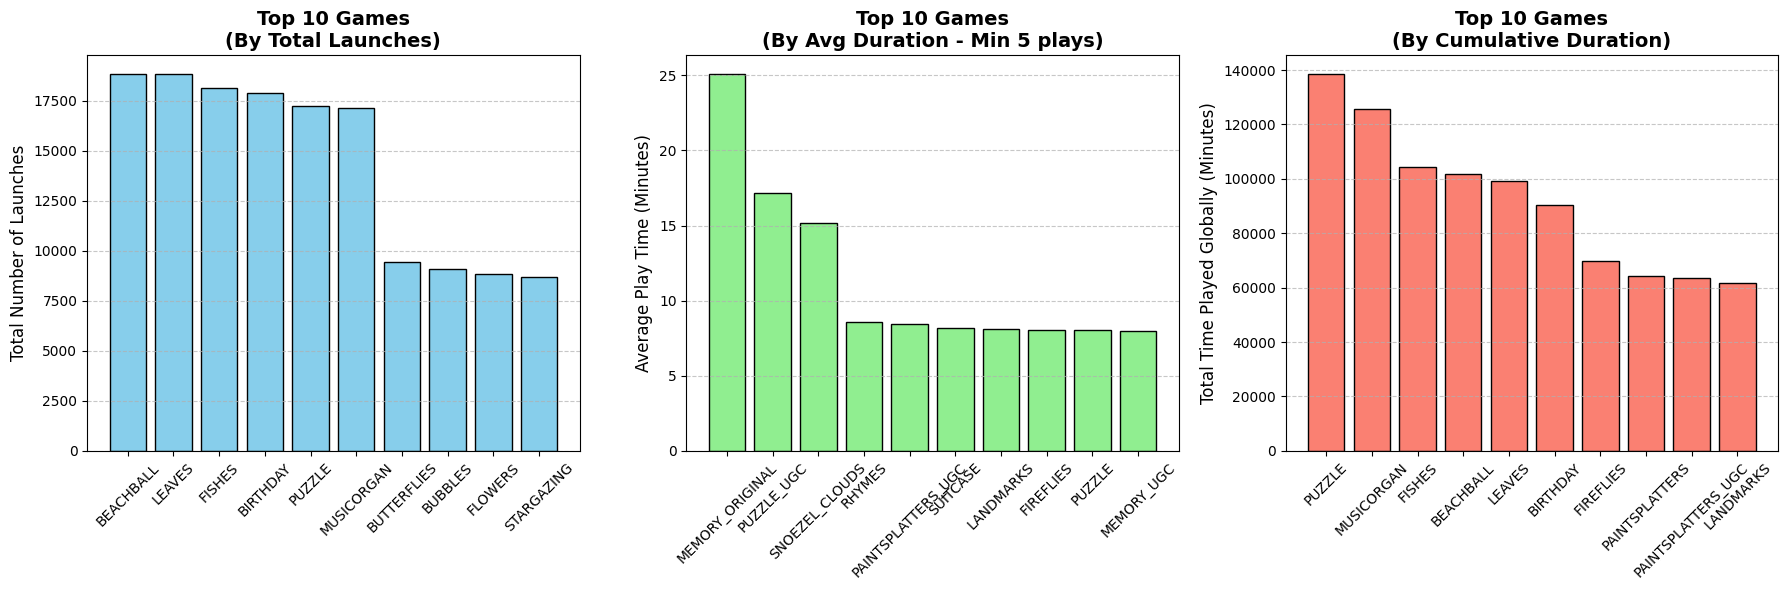

In [20]:
global_stats = df_sessions.groupby('generic_string').agg(
    total_launches=('game_uuid', 'count'),          # Number of times launched
    avg_duration=('duration_minutes', 'mean'),      # Average session duration
    total_duration=('duration_minutes', 'sum')      # Cumulative session duration
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_launches = global_stats.sort_values('total_launches', ascending=False).head(10)
axes[0].bar(top_launches['generic_string'], top_launches['total_launches'], color='skyblue', edgecolor='black')
axes[0].set_title('Top 10 Games\n(By Total Launches)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Number of Launches', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

valid_avg_games = global_stats[global_stats['total_launches'] >= 5] 
top_avg = valid_avg_games.sort_values('avg_duration', ascending=False).head(10)
axes[1].bar(top_avg['generic_string'], top_avg['avg_duration'], color='lightgreen', edgecolor='black')
axes[1].set_title('Top 10 Games\n(By Avg Duration - Min 5 plays)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Play Time (Minutes)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

top_cumulative = global_stats.sort_values('total_duration', ascending=False).head(10)
axes[2].bar(top_cumulative['generic_string'], top_cumulative['total_duration'], color='salmon', edgecolor='black')
axes[2].set_title('Top 10 Games\n(By Cumulative Duration)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Total Time Played Globally (Minutes)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
plt.tight_layout()
plt.show()

**<h4>Usage trend since activation</h4>**

In [21]:
daily_usage = df_games.groupby(['hostname', 'days_since_activation']).size().reset_index(name='games_played')

print("\nDaily game counts per device:")
print(daily_usage.head(10))

consistency_check = daily_usage.groupby('hostname')['days_since_activation'].nunique().reset_index(name='total_active_days')

print("\nTotal days each device was active:")
print(consistency_check.head())

print(df_query['activation_date'].value_counts())


Daily game counts per device:
          hostname  days_since_activation  games_played
0  hol1c1b0d97884a                      0             8
1  hol1c1b0d97884a                      1            22
2  hol408d5c128ce8                      0            53
3  hol408d5c128ce8                     34            29
4  hol408d5ce3b16b                      0            27
5  hol408d5ce3c5d9                      0            11
6  holb42e99393b27                      0            31
7  holb42e99586d00                      0            25
8  holb42e99b77b83                      0             8
9  holb42e99b77b83                      1            18

Total days each device was active:
          hostname  total_active_days
0  hol1c1b0d97884a                  2
1  hol408d5c128ce8                  2
2  hol408d5ce3b16b                  1
3  hol408d5ce3c5d9                  1
4  holb42e99393b27                  1
activation_date
2025-12-03    67063
2024-06-24    63158
2026-03-05    44651
2025-11-25   

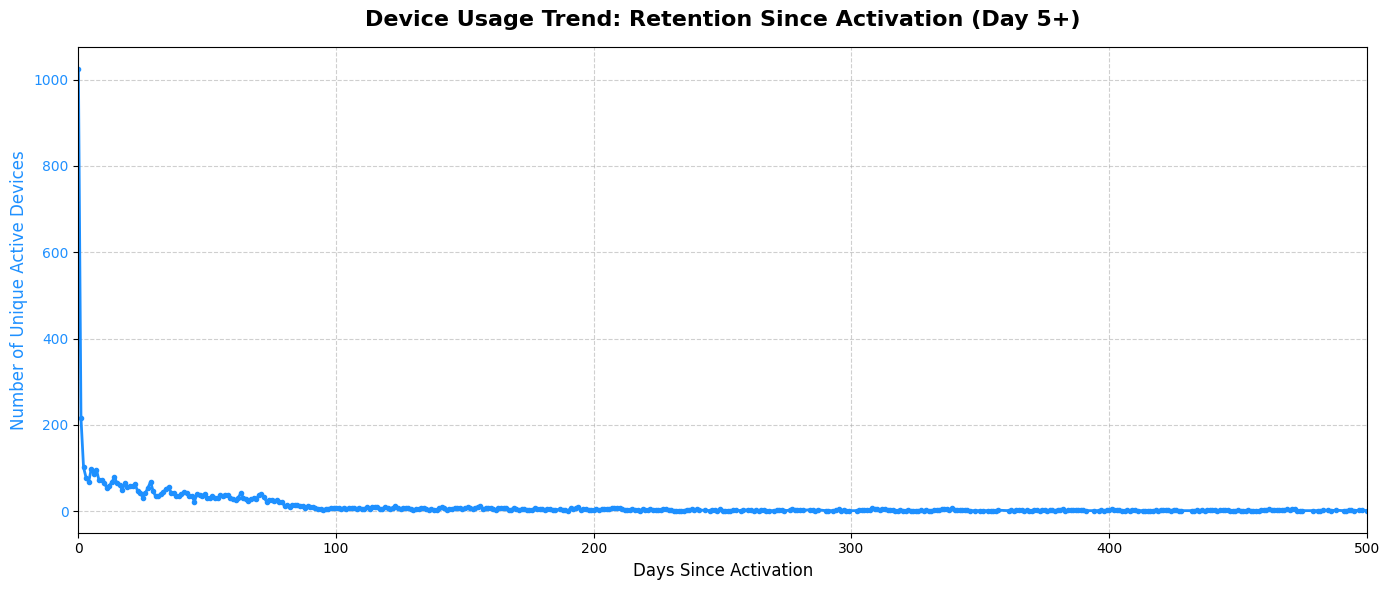

In [22]:
daily_retention = df_query.groupby('days_since_activation')['hostname'].nunique().reset_index(name='unique_devices')
daily_retention = daily_retention.sort_values('days_since_activation')

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    daily_retention['days_since_activation'],
    daily_retention['unique_devices'],
    marker='.', linestyle='-', color='dodgerblue', linewidth=2,
    label='Active Devices'
)
ax1.set_xlabel('Days Since Activation', fontsize=12)
ax1.set_ylabel('Number of Unique Active Devices', fontsize=12, color='dodgerblue')
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.set_xlim(left=0, right=500)
ax1.grid(True, linestyle='--', alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()

ax1.set_title('Device Usage Trend: Retention Since Activation (Day 5+)', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

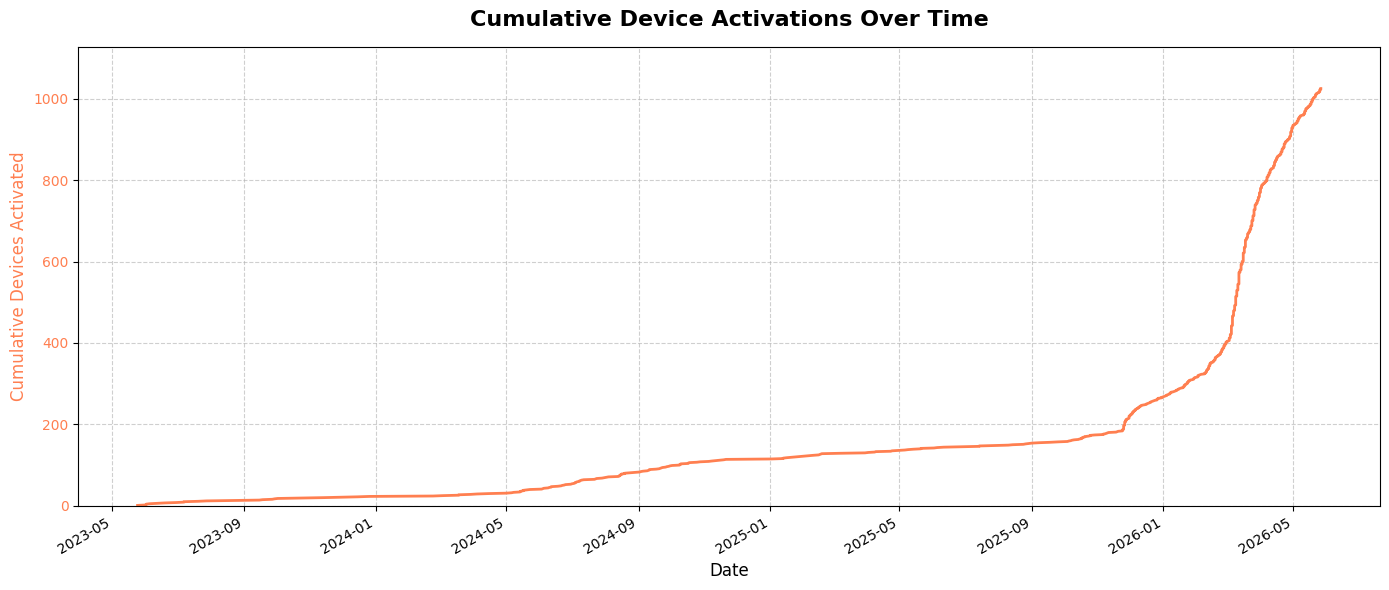

In [23]:
device_activations = df_query.drop_duplicates(subset='hostname')[['hostname', 'activation_date']].copy()
device_activations = device_activations.sort_values('activation_date').reset_index(drop=True)
device_activations['cumulative_devices'] = range(1, len(device_activations) + 1)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    pd.to_datetime(device_activations['activation_date']),
    device_activations['cumulative_devices'],
    color='coral', linewidth=2
)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Devices Activated', fontsize=12, color='coral')
ax.tick_params(axis='y', labelcolor='coral')
ax.set_ylim(0, len(device_activations) * 1.1)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title('Cumulative Device Activations Over Time', fontsize=16, fontweight='bold', pad=15)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

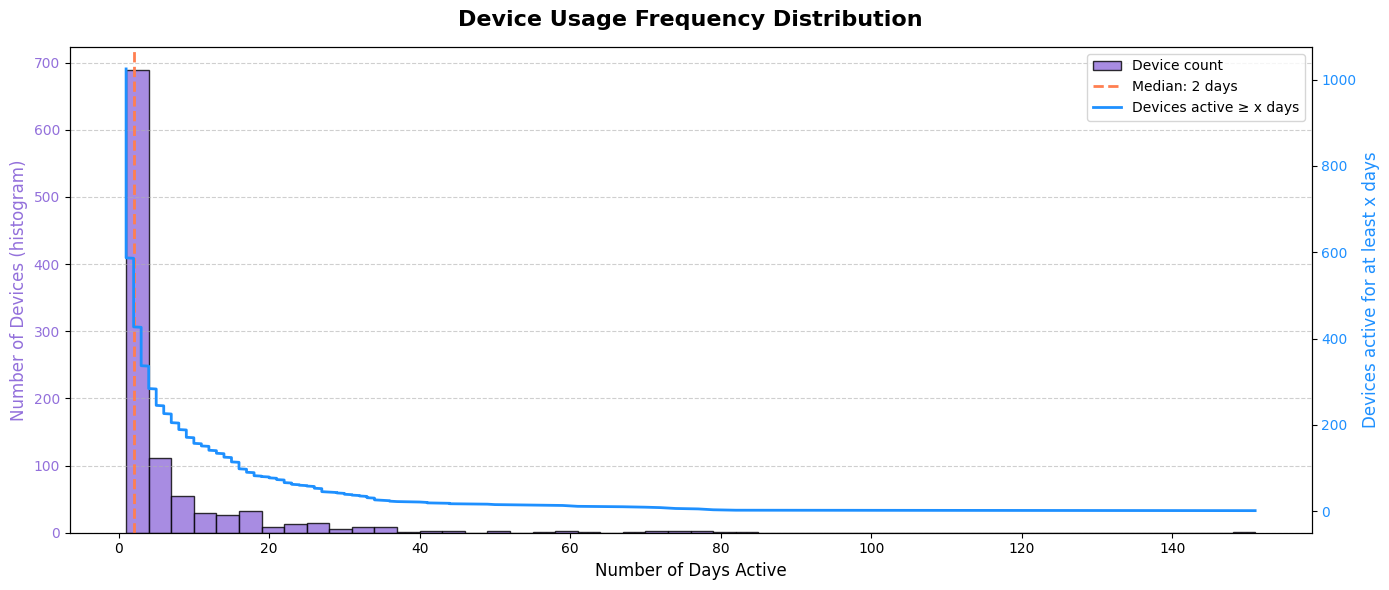

count    1025.000000
mean        6.066341
std        11.446013
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       151.000000
Name: active_days, dtype: float64


In [25]:
device_active_days = df_query.groupby('hostname')['date'].nunique().reset_index(name='active_days')

# Sort and compute cumulative device count
sorted_days = device_active_days['active_days'].sort_values()
cumulative = range(len(sorted_days), 0, -1)  # devices active for AT LEAST x days

fig, ax1 = plt.subplots(figsize=(14, 6))

# Histogram on ax1
ax1.hist(device_active_days['active_days'], bins=50, color='mediumpurple', edgecolor='black', alpha=0.8, label='Device count')
ax1.set_xlabel('Number of Days Active', fontsize=12)
ax1.set_ylabel('Number of Devices (histogram)', fontsize=12, color='mediumpurple')
ax1.tick_params(axis='y', labelcolor='mediumpurple')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

median_days = device_active_days['active_days'].median()
ax1.axvline(median_days, color='coral', linestyle='--', linewidth=2, label=f'Median: {median_days:.0f} days')

# Cumulative line on ax2
ax2 = ax1.twinx()
ax2.plot(sorted(sorted_days), cumulative, color='dodgerblue', linewidth=2, label='Devices active ≥ x days')
ax2.set_ylabel('Devices active for at least x days', fontsize=12, color='dodgerblue')
ax2.tick_params(axis='y', labelcolor='dodgerblue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

ax1.set_title('Device Usage Frequency Distribution', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(device_active_days['active_days'].describe())

In [26]:
daily_games = df_games.groupby(['days_since_activation', 'generic_string']).size().reset_index(name='play_count')
daily_games = daily_games.sort_values(['days_since_activation', 'play_count'], ascending=[True, False])

top_game_per_day = daily_games.drop_duplicates(subset=['days_since_activation'])

print("--- #1 Game Played per Day Since Activation ---")
print(top_game_per_day.head(15))

--- #1 Game Played per Day Since Activation ---
      days_since_activation      generic_string  play_count
61                        0              LEAVES        2836
156                       1           BEACHBALL        2259
309                       2              FISHES         676
448                       3          MUSICORGAN         399
548                       4              LEAVES         308
673                       5              PUZZLE         474
725                       6            BIRTHDAY         241
840                       7           BEACHBALL         209
997                       8              LEAVES         188
1142                      9        SPINNINGTOPS         367
1169                     10           BEACHBALL         323
1297                     11              FISHES         254
1449                     12  PAINTSPLATTERS_UGC         382
1504                     13            BIRTHDAY         273
1616                     14           BEACHBALL     

**<h4>Popular games by device type</h4>**

In [27]:
df_games['device_type'].value_counts()

device_type
2    311580
0    117173
3      6798
5      3237
4       427
Name: count, dtype: int64

In [28]:
games_per_device_type = df_games.groupby(['device_type', 'generic_string']).size().reset_index(name='play_count')

games_per_device_type = games_per_device_type.sort_values(['device_type', 'play_count'], ascending=[True, False])

print("--- Most Popular Games per Device Type ---")
print(games_per_device_type.groupby('device_type').head(5))

--- Most Popular Games per Device Type ---
     device_type generic_string  play_count
10             0      BEACHBALL        5868
57             0         LEAVES        5789
43             0         FISHES        5482
13             0     BIRDFEEDER        4311
54             0          KITES        4278
199            2         LEAVES       18004
148            2      BEACHBALL       17880
184            2         FISHES       17242
152            2       BIRTHDAY       17132
226            2         PUZZLE       16652
293            3        BUBBLES         279
275            3       ANEMONES         277
297            3    BUTTERFLIES         277
285            3      BEACHBALL         276
328            3          KITES         275
447            4     TOVER_PETS          27
409            4    BUTTERFLIES          25
406            4     BIRDFEEDER          20
413            4         FISHES          20
403            4       ANEMONES          18
490            5         LEAVES  

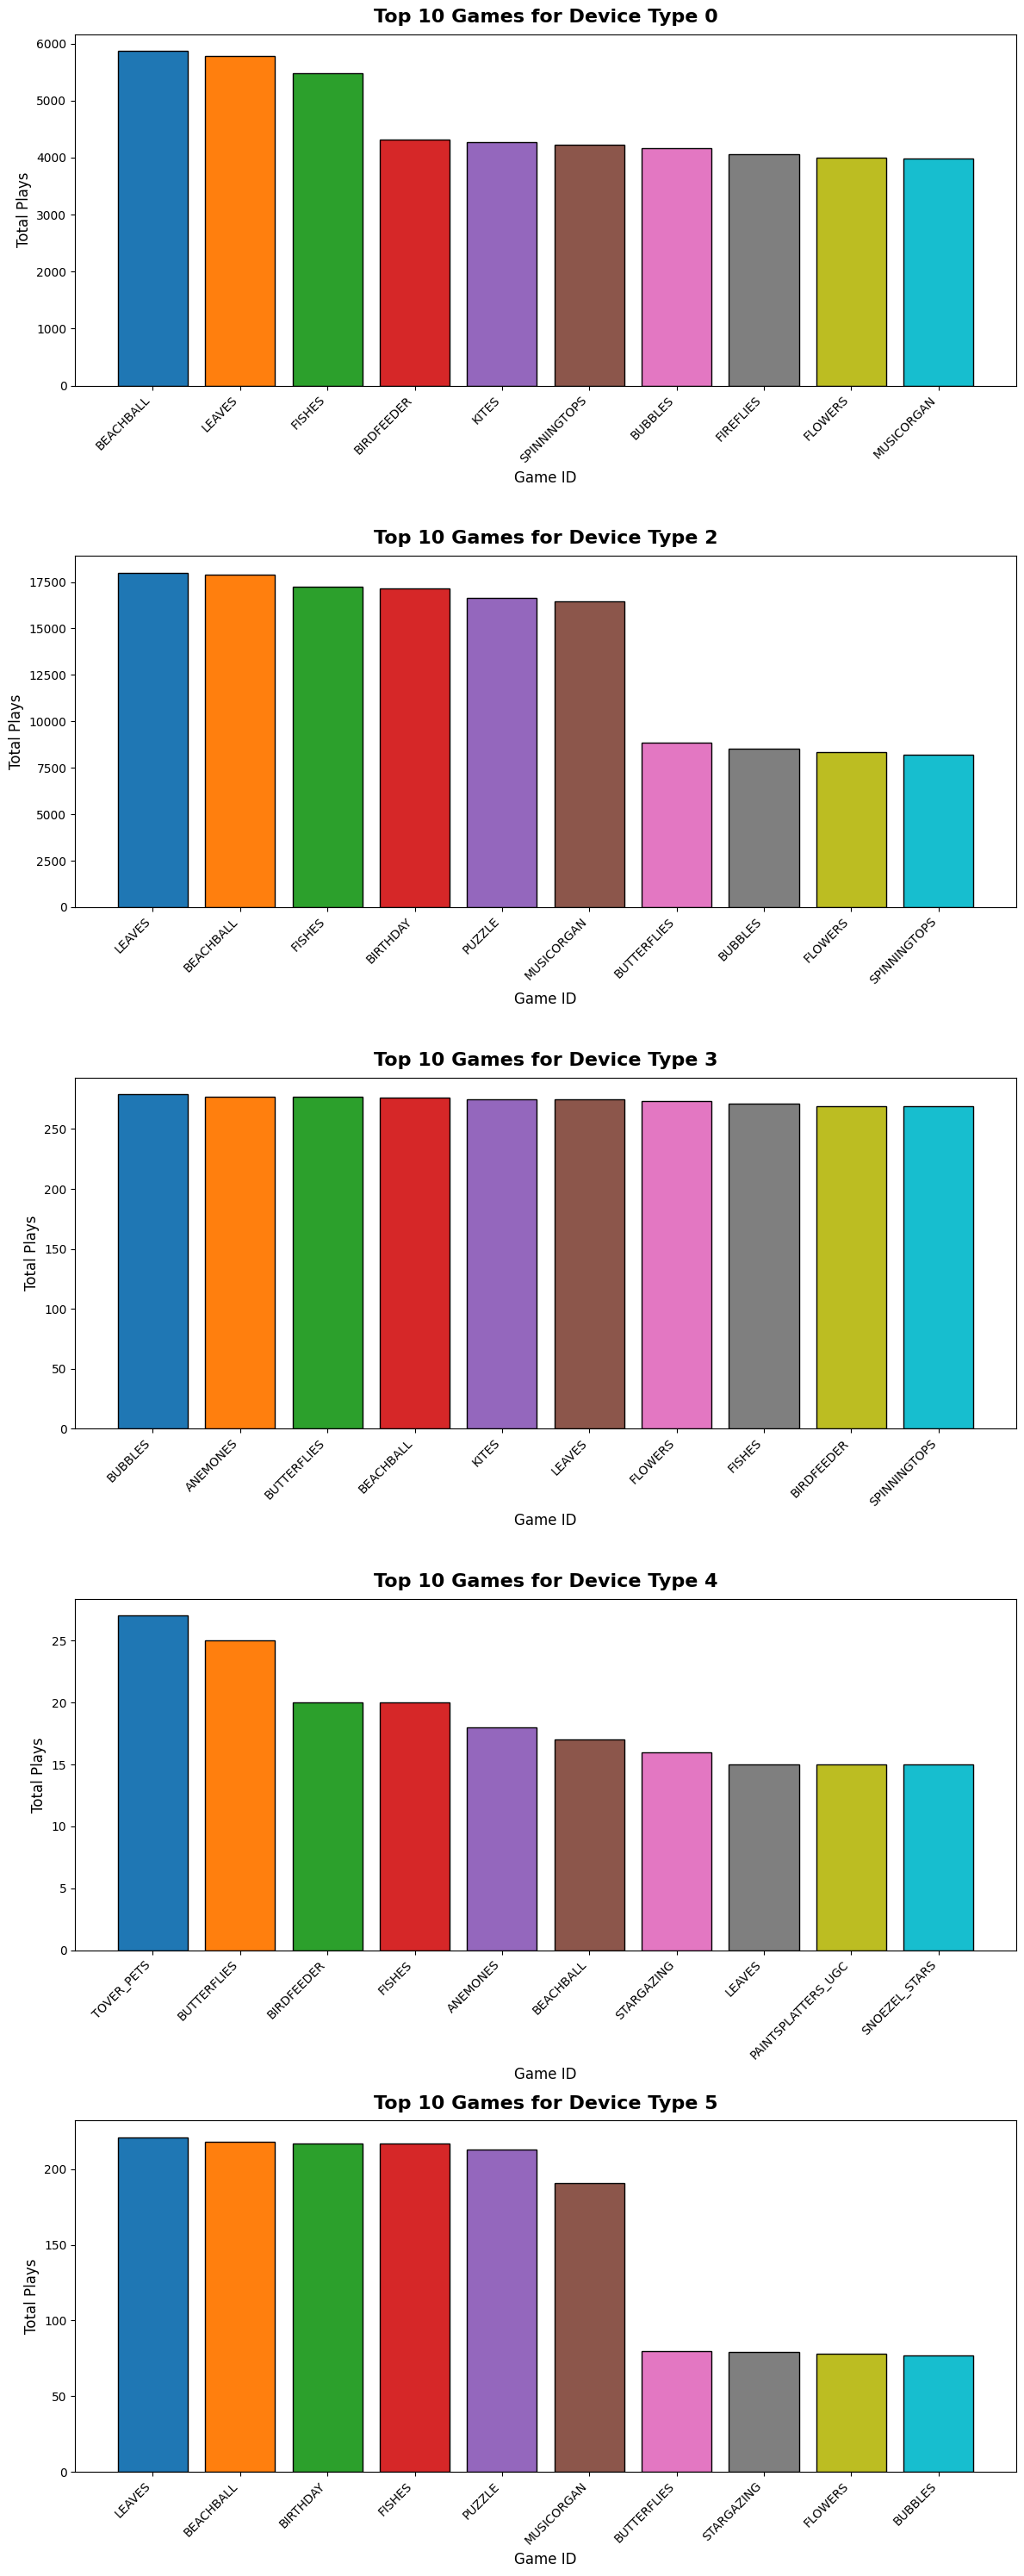

In [29]:
games_per_device = df_games.groupby(['device_type', 'generic_string']).size().reset_index(name='play_count')
games_per_device = games_per_device.sort_values(['device_type', 'play_count'], ascending=[True, False])

top_games_per_device = games_per_device.groupby('device_type').head(10)

unique_devices = top_games_per_device['device_type'].unique()

fig, axes = plt.subplots(nrows=len(unique_devices), ncols=1, figsize=(12, 6 * len(unique_devices)))

if len(unique_devices) == 1:
    axes = [axes]

colors = plt.cm.tab10.colors

for i, device in enumerate(unique_devices):
    device_data = top_games_per_device[top_games_per_device['device_type'] == device]
    axes[i].bar(device_data['generic_string'], device_data['play_count'], color=colors, edgecolor='black')
    axes[i].set_title(f'Top 10 Games for Device Type {device}', fontsize=16, fontweight='bold', pad=10)
    axes[i].set_xlabel('Game ID', fontsize=12)
    axes[i].set_ylabel('Total Plays', fontsize=12)
    axes[i].set_xticks(range(len(device_data['generic_string'])))
    axes[i].set_xticklabels(device_data['generic_string'], ha='right', rotation=45)

plt.tight_layout()
plt.show()

**<h4>Trends by country/region</h4>**

In [30]:
df_query['geoip.country_code'].value_counts()

geoip.country_code
US    350461
AU    154484
CA    111309
GB    107255
FR     70853
DE     35610
NL     22346
IE     14224
SE      3364
NO      2300
BE      2026
UK      1392
CH       737
DK        67
Name: count, dtype: int64

In [31]:
df_query['geoip.country_code'] = df_query['geoip.country_code'].replace('-', np.nan)
df_regions = df_query[df_query['geoip.country_code'].notnull()].value_counts().reset_index()

In [32]:
import country_converter as coco

df_regions['region'] = coco.convert(names=df_regions['geoip.country_code'], to='continent')

print(df_regions[['geoip.country_code', 'region']].value_counts())

geoip.country_code  region 
AU                  Oceania    76094
US                  America    33547
CA                  America    33286
FR                  Europe     29434
DE                  Europe     13281
GB                  Europe      9255
SE                  Europe      2151
NL                  Europe       942
NO                  Europe       633
UK                  Europe       295
BE                  Europe       262
CH                  Europe        84
IE                  Europe        63
Name: count, dtype: int64


--- Total Unique Devices per Region ---
device_type     0      2    3    4
region                            
America      73.0   55.0  0.0  0.0
Europe       65.0  130.0  7.0  2.0
Oceania       9.0    6.0  0.0  0.0


<Axes: title={'center': 'Device Types by Region'}, xlabel='region'>

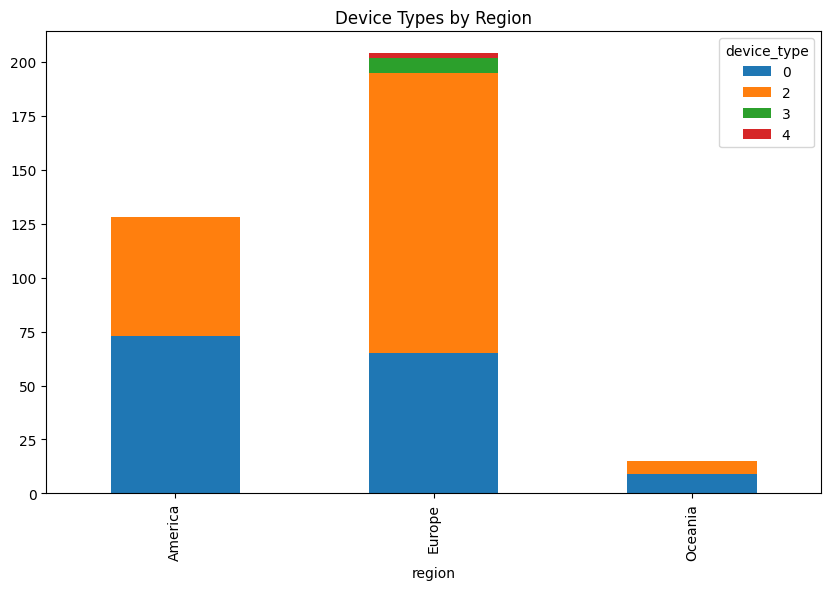

In [33]:
devices_per_region = df_regions.groupby(['region', 'device_type'])['hostname'].nunique().reset_index(name='device_count')

per_region_pivot = devices_per_region.pivot(index='region', columns='device_type', values='device_count').fillna(0)

print("--- Total Unique Devices per Region ---")
print(per_region_pivot.head(10))

per_region_pivot.head(10).plot(kind='bar', stacked=True, figsize=(10,6), title="Device Types by Region")

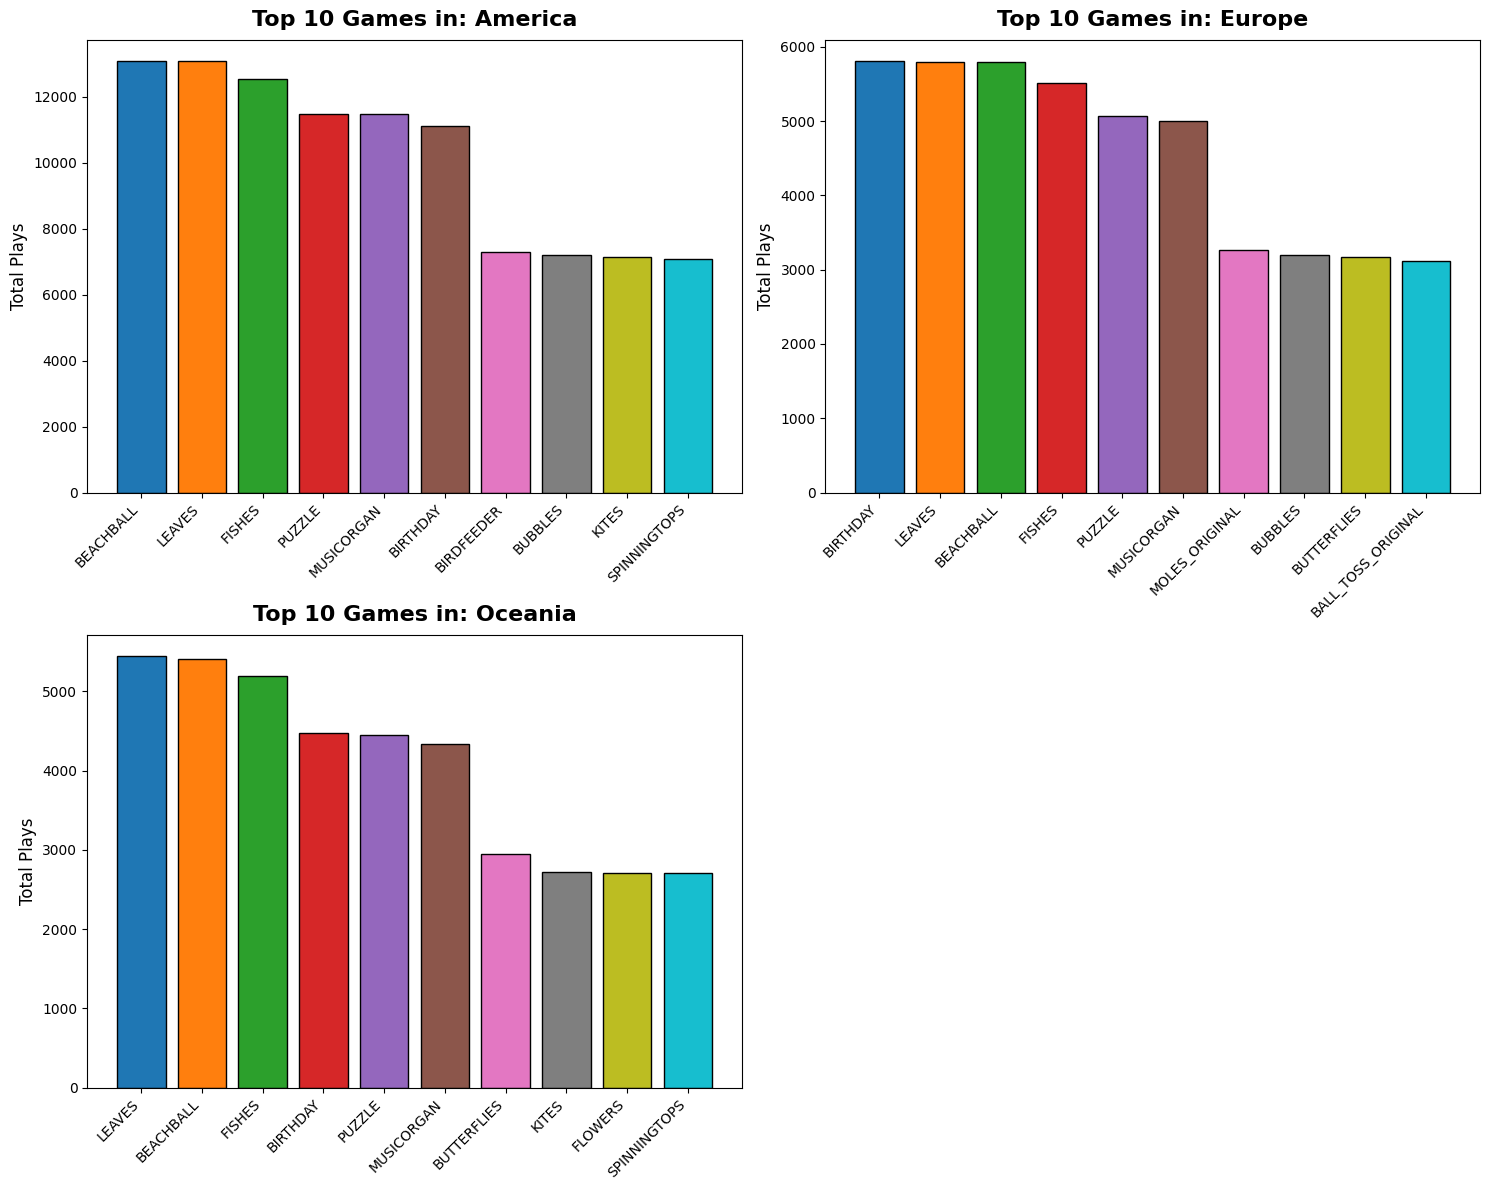

In [34]:
df_games = df_games[df_games['geoip.country_code']!='-'].copy()

df_games['region'] = coco.convert(names=df_games['geoip.country_code'], to='continent')
region_games = df_games.groupby(['region', 'generic_string']).size().reset_index(name='play_count')
region_games = region_games.sort_values(['region', 'play_count'], ascending=[True, False])

top_10_per_region = region_games.groupby('region').head(10)
unique_regions = top_10_per_region['region'].unique()

cols = 2
rows = math.ceil(len(unique_regions) / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 6 * rows))
axes = axes.flatten()

for i, region in enumerate(unique_regions):
    region_data = top_10_per_region[top_10_per_region['region'] == region]
    
    axes[i].bar(region_data['generic_string'], region_data['play_count'], color=colors, edgecolor='black')
    axes[i].set_title(f'Top 10 Games in: {region}', fontsize=16, fontweight='bold', pad=10)
    axes[i].set_ylabel('Total Plays', fontsize=12)
    axes[i].set_xticks(range(len(region_data['generic_string'])))
    axes[i].set_xticklabels(region_data['generic_string'], ha='right', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

--- Total Unique Devices per Country ---
device_type            0     2    3    4
geoip.country_code                      
AU                   9.0   6.0  0.0  0.0
BE                   1.0   1.0  0.0  0.0
CA                  22.0  19.0  0.0  0.0
CH                   0.0   2.0  0.0  0.0
DE                   9.0  22.0  1.0  0.0
FR                  27.0  69.0  3.0  1.0
GB                  17.0  15.0  0.0  0.0
IE                   0.0   1.0  1.0  0.0
NL                   7.0  17.0  2.0  1.0
NO                   1.0   1.0  0.0  0.0


<Axes: title={'center': 'Device Types by Country'}, xlabel='geoip.country_code'>

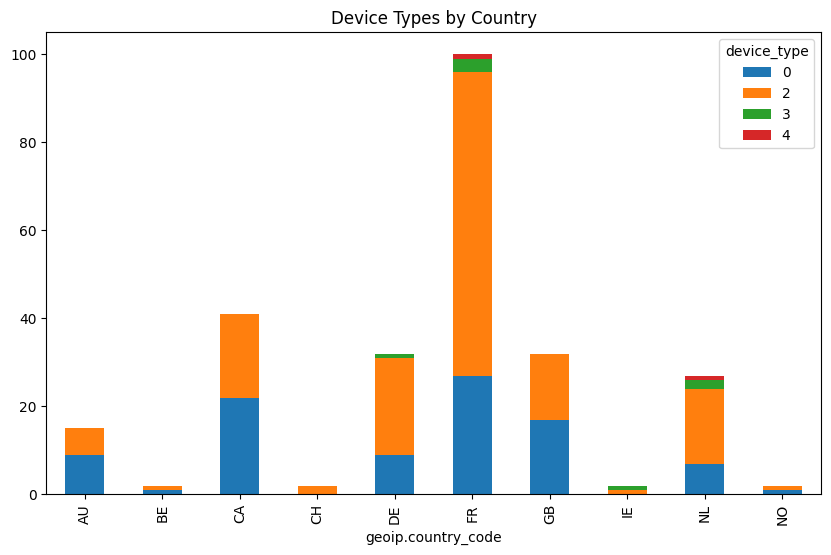

In [35]:
devices_per_country = df_regions.groupby(['geoip.country_code', 'device_type'])['hostname'].nunique().reset_index(name='device_count')

device_pivot = devices_per_country.pivot(index='geoip.country_code', columns='device_type', values='device_count').fillna(0)

print("--- Total Unique Devices per Country ---")
print(device_pivot.head(10))

device_pivot.head(10).plot(kind='bar', stacked=True, figsize=(10,6), title="Device Types by Country")

In [36]:
country_games = df_games.groupby(['geoip.country_code', 'generic_string']).size().reset_index(name='play_count')
country_games = country_games.sort_values(['geoip.country_code', 'play_count'], ascending=[True, False])

top_5_per_country = country_games.groupby('geoip.country_code').head(5)

print("--- Top 5 Games per Country ---")
print(top_5_per_country)

--- Top 5 Games per Country ---
     geoip.country_code generic_string  play_count
50                   AU         LEAVES        5439
8                    AU      BEACHBALL        5402
38                   AU         FISHES        5194
12                   AU       BIRTHDAY        4473
74                   AU         PUZZLE        4442
...                 ...            ...         ...
1260                 US      BEACHBALL        8221
1301                 US         LEAVES        8217
1290                 US         FISHES        7830
1324                 US         PUZZLE        6864
1312                 US     MUSICORGAN        6796

[70 rows x 3 columns]


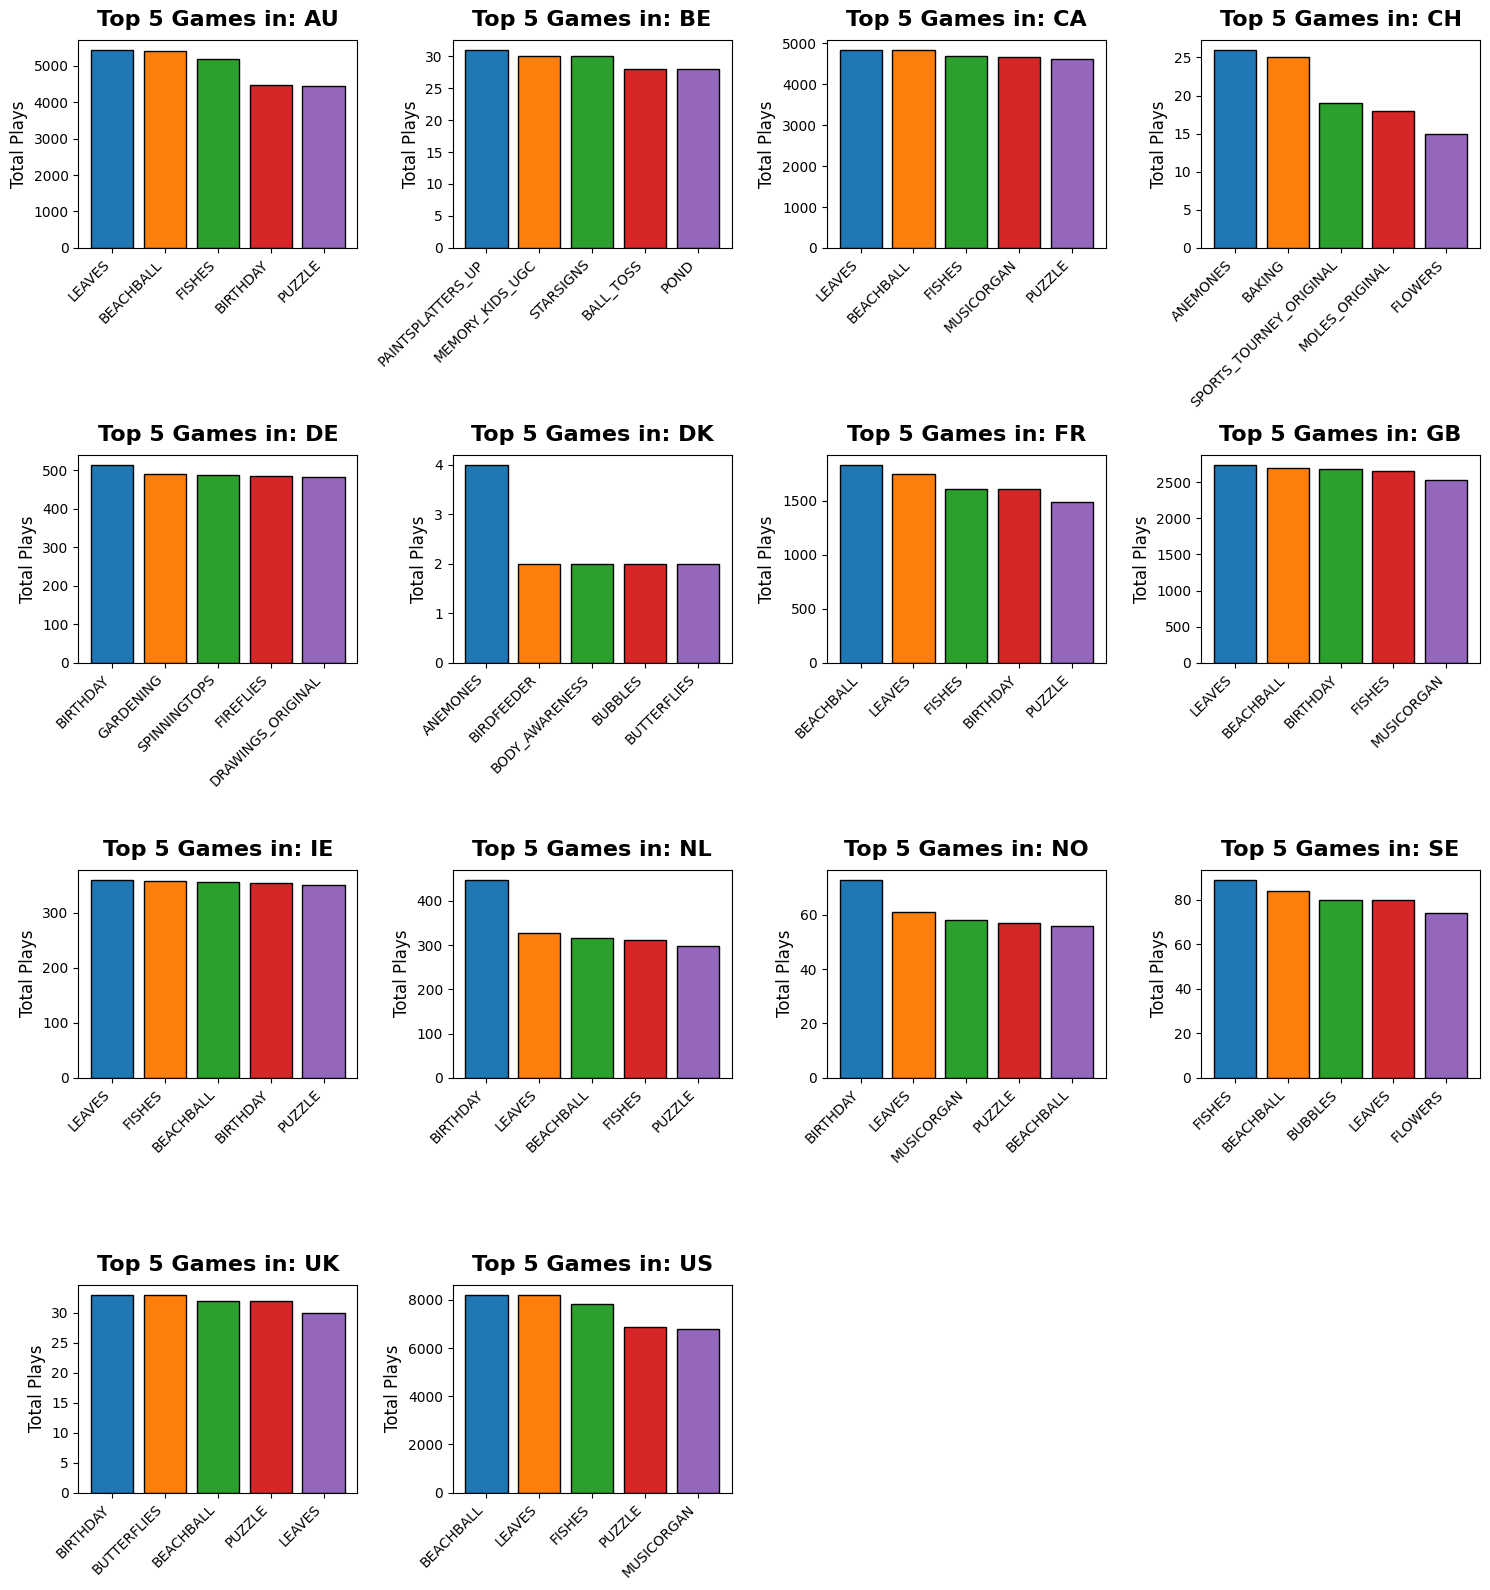

In [37]:
unique_countries = top_5_per_country['geoip.country_code'].unique()
cols = 4
rows = math.ceil(len(unique_countries) / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, country in enumerate(unique_countries):
    country_data = top_5_per_country[top_5_per_country['geoip.country_code'] == country]
    
    axes[i].bar(country_data['generic_string'], country_data['play_count'], color=colors, edgecolor='black')
    axes[i].set_title(f'Top 5 Games in: {country}', fontsize=16, fontweight='bold', pad=10)
    axes[i].set_ylabel('Total Plays', fontsize=12)
    axes[i].set_xticks(range(len(country_data['generic_string'])))
    axes[i].set_xticklabels(country_data['generic_string'], ha='right', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
